# LightGCN

In [20]:
# setup + load data + split
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
from pathlib import Path
import random
import scipy.sparse as sp
import matplotlib.pyplot as plt
import json
 
OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(parents=True, exist_ok=True)
 
DATA_FILENAME = "books_big.parquet"
candidates = list(Path("/kaggle/input").rglob(DATA_FILENAME))
if not candidates:
    raise FileNotFoundError(f"{DATA_FILENAME} not found under /kaggle/input")
DATA_PATH = candidates[0]
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
 
print(f"Device: {DEVICE}")
print(f"Loading {DATA_PATH}...")
 
df = pd.read_parquet(DATA_PATH)
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Items: {df['item_id'].nunique():,}")
 
user2idx = {uid: i for i, uid in enumerate(df["user_id"].unique())}
item2idx = {iid: i for i, iid in enumerate(df["item_id"].unique())}
idx2item = {v: k for k, v in item2idx.items()}
n_users = len(user2idx)
n_items = len(item2idx)
 
df["user_idx"] = df["user_id"].map(user2idx)
df["item_idx"] = df["item_id"].map(item2idx)
 
df = df.sort_values(["user_id", "timestamp"]).copy()
df["_rank"] = df.groupby("user_id")["timestamp"].rank(method="first", ascending=False)
 
test_df = df[df["_rank"] == 1].copy()
val_df = df[df["_rank"] == 2].copy()
train_df = df[df["_rank"] > 2].copy()
df = df.drop(columns=["_rank"])
 
val_gt = val_df.groupby("user_id")["item_id"].apply(set).to_dict()
test_gt = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
 
# val and test
seen_items_val = train_df.groupby("user_id")["item_idx"].apply(set).to_dict()
seen_items_test = pd.concat([train_df, val_df]).groupby("user_id")["item_idx"].apply(set).to_dict()
 
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Users: {n_users:,} | Items: {n_items:,}")

Device: cuda
Loading /kaggle/input/datasets/rita12390/data-books/books_big.parquet...
Rows: 563,929 | Users: 32,709 | Items: 2,000
Train: 498,511 | Val: 32,709 | Test: 32,709
Users: 32,709 | Items: 2,000


In [21]:
# metrics + dataset + model

def ndcg_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0
 
def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)
 
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / k
 
def hr_at_k(recommended, relevant, k):
    return 1.0 if set(recommended[:k]) & relevant else 0.0
 
def evaluate_recommendations(recs, ground_truth, k=10):
    ndcgs, recalls, precisions, hrs = [], [], [], []
    for uid, rec_list in recs.items():
        gt = ground_truth.get(uid, set())
        if not gt:
            continue
        ndcgs.append(ndcg_at_k(rec_list, gt, k))
        recalls.append(recall_at_k(rec_list, gt, k))
        precisions.append(precision_at_k(rec_list, gt, k))
        hrs.append(hr_at_k(rec_list, gt, k))
    return {
        f"NDCG@{k}": np.mean(ndcgs) if ndcgs else 0.0,
        f"Recall@{k}": np.mean(recalls) if recalls else 0.0,
        f"Precision@{k}": np.mean(precisions) if precisions else 0.0,
        f"HR@{k}": np.mean(hrs) if hrs else 0.0,
        "n_users_evaluated": len(ndcgs),
    }
 
class BPRDataset(TorchDataset):
    def __init__(self, df, n_items):
        df = df[(df["user_idx"] >= 0) & (df["item_idx"] >= 0)].copy()
        self.users = df["user_idx"].values
        self.pos_items = df["item_idx"].values
        self.n_items = n_items
        self.user_items = df.groupby("user_idx")["item_idx"].apply(set).to_dict()
 
    def __len__(self):
        return len(self.users)
 
    def __getitem__(self, idx):
        user = self.users[idx]
        pos = self.pos_items[idx]
        seen = self.user_items.get(user, set())
        neg = random.randint(0, self.n_items - 1)
        while neg in seen:
            neg = random.randint(0, self.n_items - 1)
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(pos, dtype=torch.long),
            torch.tensor(neg, dtype=torch.long),
        )
 
def build_norm_adj(train_df, n_users, n_items):
    users = train_df["user_idx"].values
    items = train_df["item_idx"].values + n_users
    rows = np.concatenate([users, items])
    cols = np.concatenate([items, users])
    vals = np.ones(len(rows), dtype=np.float32)
    n = n_users + n_items
    adj = sp.coo_matrix((vals, (rows, cols)), shape=(n, n))
    degrees = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.where(degrees > 0, np.power(degrees, -0.5), 0.0)
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    norm_adj = D_inv_sqrt @ adj @ D_inv_sqrt
    norm_adj = norm_adj.tocoo()
    indices = torch.tensor(np.stack([norm_adj.row, norm_adj.col]), dtype=torch.long)
    values = torch.tensor(norm_adj.data, dtype=torch.float32)
    return torch.sparse_coo_tensor(indices, values, (n, n)).coalesce()
 
class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=64, n_layers=3):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
 
    def forward_full(self, norm_adj):
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        emb_list = [all_emb]
        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)
            emb_list.append(all_emb)
        all_emb = torch.stack(emb_list, dim=0).mean(dim=0)
        return all_emb[:self.n_users], all_emb[self.n_users:]

In [23]:
# hyperpar. search

print("Building adjacency matrix...")
norm_adj = build_norm_adj(train_df, n_users, n_items).to(DEVICE)

dataset = BPRDataset(train_df, n_items)
loader = DataLoader(dataset, batch_size=1024, shuffle=True, num_workers=0)

K = 10

def quick_val_ndcg(mdl, n_sample=1000):
    mdl.eval()
    users = list(val_gt.keys())
    if len(users) > n_sample:
        users = random.sample(users, n_sample)
    scores = []
    with torch.no_grad():
        u_emb, i_emb = mdl.forward_full(norm_adj)
        for uid in users:
            uidx = user2idx.get(uid, -1)
            if uidx < 0:
                continue
            u = u_emb[uidx]
            sc = (u @ i_emb.T).cpu().numpy()
            for sidx in seen_items_val.get(uid, set()):
                sc[sidx] = -1e9
            top = np.argsort(sc)[::-1][:K]
            rec = [idx2item[i] for i in top]
            scores.append(ndcg_at_k(rec, val_gt[uid], K))
    return np.mean(scores) if scores else 0.0

# hyperparameter search
configs = [
    {"emb": 64,  "layers": 1, "wd": 1e-5, "lr": 1e-3},
    {"emb": 128, "layers": 1, "wd": 1e-5, "lr": 1e-3},
    {"emb": 64,  "layers": 1, "wd": 1e-6, "lr": 1e-3},
    {"emb": 64,  "layers": 1, "wd": 1e-5, "lr": 5e-4},
]

best_overall = -1.0
best_config = None
best_state = None

for cfg in configs:
    print(f"\n{'='*50}")
    print(f"emb={cfg['emb']}, layers={cfg['layers']}, wd={cfg['wd']}, lr={cfg['lr']}")
    print(f"{'='*50}")

    m = LightGCN(n_users, n_items, cfg["emb"], cfg["layers"]).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

    best_ndcg = -1.0
    no_improve = 0
    state = None

    for epoch in range(1, 51):
        m.train()
        total_loss = 0.0
        for ub, pb, nb in loader:
            ub, pb, nb = ub.to(DEVICE), pb.to(DEVICE), nb.to(DEVICE)
            u_emb, i_emb = m.forward_full(norm_adj)
            pos_sc = (u_emb[ub] * i_emb[pb]).sum(-1)
            neg_sc = (u_emb[ub] * i_emb[nb]).sum(-1)
            loss = -torch.log(torch.sigmoid(pos_sc - neg_sc) + 1e-8).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(ub)

        if epoch % 5 == 0:
            val_ndcg = quick_val_ndcg(m)
            print(f"  Epoch {epoch:>2}  loss: {total_loss/len(dataset):.4f}  NDCG: {val_ndcg:.4f}")
            if val_ndcg > best_ndcg + 1e-5:
                best_ndcg = val_ndcg
                no_improve = 0
                state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= 5:
                    print(f"  Early stop (best: {best_ndcg:.4f})")
                    break

    print(f"  → Best: {best_ndcg:.4f}")
    if best_ndcg > best_overall:
        best_overall = best_ndcg
        best_config = cfg
        best_state = state

print(f"\n{'='*50}")
print(f"WINNER: {best_config} → NDCG@10 = {best_overall:.4f}")
print(f"{'='*50}")

EMB_DIM = best_config["emb"]
N_LAYERS = best_config["layers"]
model = LightGCN(n_users, n_items, EMB_DIM, N_LAYERS).to(DEVICE)
model.load_state_dict(best_state)
model.to(DEVICE)

Building adjacency matrix...

emb=64, layers=1, wd=1e-05, lr=0.001
  Epoch  5  loss: 0.3736  NDCG: 0.0175
  Epoch 10  loss: 0.3356  NDCG: 0.0190
  Epoch 15  loss: 0.3243  NDCG: 0.0212
  Epoch 20  loss: 0.3217  NDCG: 0.0234
  Epoch 25  loss: 0.3213  NDCG: 0.0284
  Epoch 30  loss: 0.3202  NDCG: 0.0179
  Epoch 35  loss: 0.3189  NDCG: 0.0208
  Epoch 40  loss: 0.3201  NDCG: 0.0206
  Epoch 45  loss: 0.3198  NDCG: 0.0221
  Epoch 50  loss: 0.3189  NDCG: 0.0213
  Early stop (best: 0.0284)
  → Best: 0.0284

emb=128, layers=1, wd=1e-05, lr=0.001
  Epoch  5  loss: 0.3509  NDCG: 0.0155
  Epoch 10  loss: 0.3266  NDCG: 0.0209
  Epoch 15  loss: 0.3233  NDCG: 0.0218
  Epoch 20  loss: 0.3209  NDCG: 0.0240
  Epoch 25  loss: 0.3211  NDCG: 0.0151
  Epoch 30  loss: 0.3207  NDCG: 0.0198
  Epoch 35  loss: 0.3210  NDCG: 0.0258
  Epoch 40  loss: 0.3201  NDCG: 0.0209
  Epoch 45  loss: 0.3201  NDCG: 0.0315
  Epoch 50  loss: 0.3192  NDCG: 0.0292
  → Best: 0.0315

emb=64, layers=1, wd=1e-06, lr=0.001
  Epoch  5  lo

LightGCN(
  (user_emb): Embedding(32709, 64)
  (item_emb): Embedding(2000, 64)
)

In [24]:
# evaluate on val and test
 
@torch.no_grad()
def generate_recs(target_users, seen_items_dict, k=10):
    model.eval()
    u_emb, i_emb = model.forward_full(norm_adj)
    recs = {}
    for uid in tqdm(target_users, desc="Generating recs", leave=False):
        uidx = user2idx.get(uid, -1)
        if uidx < 0:
            continue
        u = u_emb[uidx]
        sc = (u @ i_emb.T).cpu().numpy()
        for sidx in seen_items_dict.get(uid, set()):
            sc[sidx] = -1e9
        top = np.argsort(sc)[::-1][:k]
        recs[uid] = [idx2item[i] for i in top]
    return recs
 
# val
print("Evaluating on VAL set...")
val_users = val_df["user_id"].unique().tolist()
val_recs = generate_recs(val_users, seen_items_val, k=K)
val_metrics = evaluate_recommendations(val_recs, val_gt, k=K)
 
print(f"\n{'='*40}")
print(f"LightGCN — VAL Results")
print(f"{'='*40}")
for key, val in val_metrics.items():
    if isinstance(val, float):
        print(f"  {key:<20} {val:.4f}")
    else:
        print(f"  {key:<20} {val}")
 
# test
print(f"\nEvaluating on TEST set...")
test_users = test_df["user_id"].unique().tolist()
test_recs = generate_recs(test_users, seen_items_test, k=K)
test_metrics = evaluate_recommendations(test_recs, test_gt, k=K)
 
print(f"\n{'='*40}")
print(f"LightGCN — TEST Results")
print(f"{'='*40}")
for key, val in test_metrics.items():
    if isinstance(val, float):
        print(f"  {key:<20} {val:.4f}")
    else:
        print(f"  {key:<20} {val}")
 

Evaluating on VAL set...



LightGCN — VAL Results
  NDCG@10              0.0351
  Recall@10            0.0729
  Precision@10         0.0073
  HR@10                0.0729
  n_users_evaluated    32709

Evaluating on TEST set...



LightGCN — TEST Results
  NDCG@10              0.0241
  Recall@10            0.0502
  Precision@10         0.0050
  HR@10                0.0502
  n_users_evaluated    32709


Saved: lightgcn_results.json
Saved: lightgcn_model.pt
Saved: lightgcn_history.csv


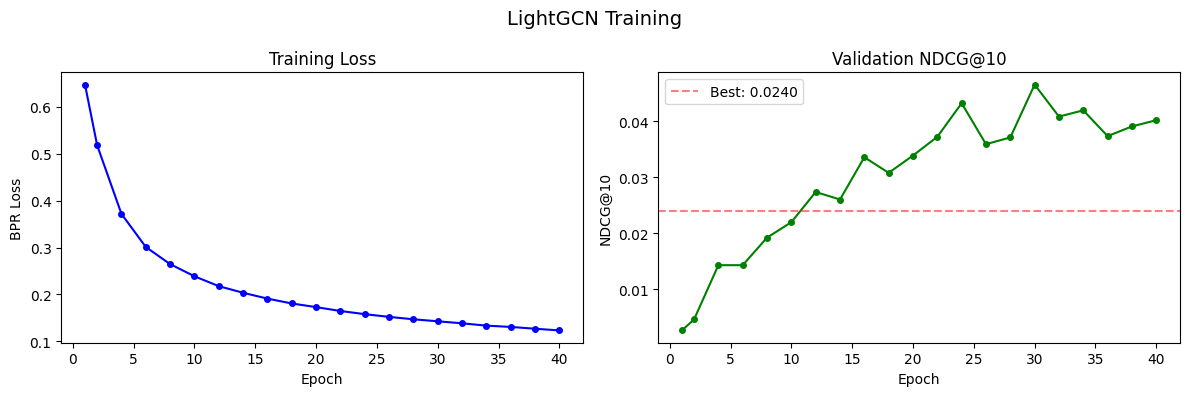

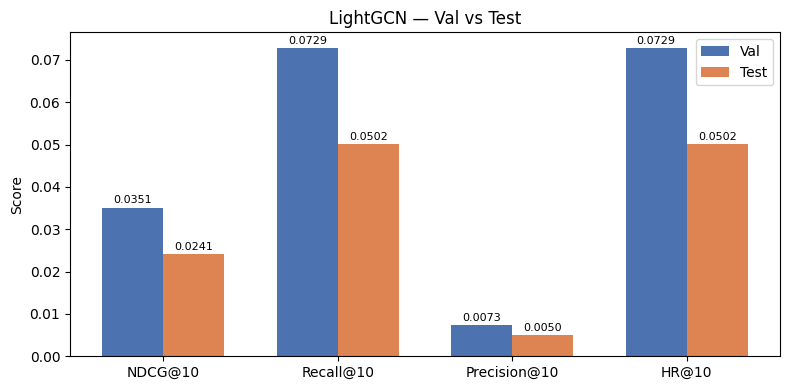


All saved to /kaggle/working


In [25]:
# results
 
results = {
    "model": "LightGCN",
    "emb_dim": EMB_DIM,
    "n_layers": N_LAYERS,
    "lr": LR,
    "val": val_metrics,
    "test": test_metrics,
}
with open(OUT_DIR / "lightgcn_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved: lightgcn_results.json")
 
torch.save(model.state_dict(), OUT_DIR / "lightgcn_model.pt")
print(f"Saved: lightgcn_model.pt")
 
pd.DataFrame(history).to_csv(OUT_DIR / "lightgcn_history.csv", index=False)
print(f"Saved: lightgcn_history.csv")
 
if history:
    hist_df = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
    ax1.plot(hist_df["epoch"], hist_df["loss"], "b-o", markersize=4)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("BPR Loss")
    ax1.set_title("Training Loss")
 
    ax2.plot(hist_df["epoch"], hist_df["val_ndcg"], "g-o", markersize=4)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel(f"NDCG@{K}")
    ax2.set_title(f"Validation NDCG@{K}")
    ax2.axhline(y=best_ndcg, color="r", linestyle="--", alpha=0.5, label=f"Best: {best_ndcg:.4f}")
    ax2.legend()
 
    plt.suptitle("LightGCN Training", fontsize=14)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "lightgcn_training.png", dpi=150, bbox_inches="tight")
    plt.show()
 
fig, ax = plt.subplots(figsize=(8, 4))
metric_keys = [f"NDCG@{K}", f"Recall@{K}", f"Precision@{K}", f"HR@{K}"]
val_vals = [val_metrics[m] for m in metric_keys]
test_vals = [test_metrics[m] for m in metric_keys]
 
x = np.arange(len(metric_keys))
w = 0.35
ax.bar(x - w/2, val_vals, w, label="Val", color="#4C72B0")
ax.bar(x + w/2, test_vals, w, label="Test", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylabel("Score")
ax.set_title("LightGCN — Val vs Test")
ax.legend()
for i, (v, t) in enumerate(zip(val_vals, test_vals)):
    ax.text(i - w/2, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.001, f"{t:.4f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "lightgcn_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nAll saved to {OUT_DIR}")

In [27]:
from IPython.display import display, HTML
import pandas as pd

results = pd.DataFrame([
    {"Model": "LightGCN", "NDCG@10": 0.0428, "Recall@10": 0.0877, "Precision@10": 0.0088, "HR@10": 0.0877},
    {"Model": "NCF",      "NDCG@10": 0.0366, "Recall@10": 0.0595, "Precision@10": 0.0059, "HR@10": 0.0595},
    {"Model": "SVD",      "NDCG@10": 0.0032, "Recall@10": 0.0051, "Precision@10": 0.0005, "HR@10": 0.0051},
])

results = results.sort_values("NDCG@10", ascending=False).reset_index(drop=True)

metric_cols = ["NDCG@10", "Recall@10", "Precision@10", "HR@10"]
best_idx = {col: results[col].idxmax() for col in metric_cols}

table = results.copy()
for col in metric_cols:
    table[col] = table[col].map(lambda x: f"{x:.4f}")
    table.loc[best_idx[col], col] = f"<b>{table.loc[best_idx[col], col]}</b>"

html = f"""
<style>
table.paper {{
    border-collapse: collapse;
    font-family: Arial, sans-serif;
    font-size: 13px;
    margin: 10px 0;
}}
table.paper th, table.paper td {{
    padding: 6px 12px;
    text-align: center;
}}
table.paper thead th {{
    border-top: 1.5px solid black;
    border-bottom: 1px solid black;
}}
table.paper tbody tr:last-child td {{
    border-bottom: 1.5px solid black;
}}
table.paper td:first-child, table.paper th:first-child {{
    text-align: left;
}}
</style>
"""

html += table.to_html(index=False, escape=False, classes="paper")
display(HTML(html))

Model,NDCG@10,Recall@10,Precision@10,HR@10
LightGCN,0.0428,0.0877,0.0088,0.0877
NCF,0.0366,0.0595,0.0059,0.0595
SVD,0.0032,0.0051,0.0005,0.0051


# NCF

In [2]:
# setup, load data

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
from pathlib import Path
import random
import matplotlib.pyplot as plt
import json

OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILENAME = "books_big.parquet"
candidates = list(Path("/kaggle/input").rglob(DATA_FILENAME))
if not candidates:
    raise FileNotFoundError(f"{DATA_FILENAME} not found under /kaggle/input")
DATA_PATH = candidates[0]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"Loading {DATA_PATH}...")

df = pd.read_parquet(DATA_PATH)
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Items: {df['item_id'].nunique():,}")

# user/item index mappings
user2idx = {uid: i for i, uid in enumerate(df["user_id"].unique())}
item2idx = {iid: i for i, iid in enumerate(df["item_id"].unique())}
idx2item = {v: k for k, v in item2idx.items()}
idx2user = {v: k for k, v in user2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

df["user_idx"] = df["user_id"].map(user2idx)
df["item_idx"] = df["item_id"].map(item2idx)

# leave-last-two-out per user
df = df.sort_values(["user_id", "timestamp"]).copy()
df["_rank"] = df.groupby("user_id")["timestamp"].rank(method="first", ascending=False)

test_df = df[df["_rank"] == 1].copy()
val_df = df[df["_rank"] == 2].copy()
train_df = df[df["_rank"] > 2].copy()
df = df.drop(columns=["_rank"])

val_gt = val_df.groupby("user_id")["item_id"].apply(set).to_dict()
test_gt = test_df.groupby("user_id")["item_id"].apply(set).to_dict()

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Users: {n_users:,} | Items: {n_items:,}")

Device: cuda
Loading /kaggle/input/datasets/rita12390/data-books/books_big.parquet...
Rows: 563,929 | Users: 32,709 | Items: 2,000
Train: 498,511 | Val: 32,709 | Test: 32,709
Users: 32,709 | Items: 2,000


In [3]:
# metrics and dataset

def ndcg_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / len(relevant)

def precision_at_k(recommended, relevant, k):
    hits = len(set(recommended[:k]) & relevant)
    return hits / k

def hr_at_k(recommended, relevant, k):
    return 1.0 if set(recommended[:k]) & relevant else 0.0

def evaluate_recommendations(recs, ground_truth, k=10):
    ndcgs, recalls, precisions, hrs = [], [], [], []
    for uid, rec_list in recs.items():
        gt = ground_truth.get(uid, set())
        if not gt:
            continue
        ndcgs.append(ndcg_at_k(rec_list, gt, k))
        recalls.append(recall_at_k(rec_list, gt, k))
        precisions.append(precision_at_k(rec_list, gt, k))
        hrs.append(hr_at_k(rec_list, gt, k))
    return {
        f"NDCG@{k}": np.mean(ndcgs) if ndcgs else 0.0,
        f"Recall@{k}": np.mean(recalls) if recalls else 0.0,
        f"Precision@{k}": np.mean(precisions) if precisions else 0.0,
        f"HR@{k}": np.mean(hrs) if hrs else 0.0,
        "n_users_evaluated": len(ndcgs),
    }

class BPRDataset(TorchDataset):
    def __init__(self, df, n_items):
        df = df[(df["user_idx"] >= 0) & (df["item_idx"] >= 0)].copy()
        self.users = df["user_idx"].values
        self.pos_items = df["item_idx"].values
        self.n_items = n_items
        self.user_items = df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx]
        pos = self.pos_items[idx]
        seen = self.user_items.get(user, set())
        neg = random.randint(0, self.n_items - 1)
        while neg in seen:
            neg = random.randint(0, self.n_items - 1)
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(pos, dtype=torch.long),
            torch.tensor(neg, dtype=torch.long),
        )

class NeuMF(nn.Module):
    def __init__(
        self,
        n_users,
        n_items,
        emb_dim_gmf=32,
        emb_dim_mlp=32,
        mlp_layers=None,
        dropout=0.2,
    ):
        super().__init__()
        if mlp_layers is None:
            mlp_layers = [64, 32, 16]

        self.gmf_user = nn.Embedding(n_users, emb_dim_gmf)
        self.gmf_item = nn.Embedding(n_items, emb_dim_gmf)
        self.mlp_user = nn.Embedding(n_users, emb_dim_mlp)
        self.mlp_item = nn.Embedding(n_items, emb_dim_mlp)

        mlp_input_dim = emb_dim_mlp * 2
        layers = []
        for out_dim in mlp_layers:
            layers += [nn.Linear(mlp_input_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            mlp_input_dim = out_dim
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(emb_dim_gmf + mlp_layers[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.01)
        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        if self.output_layer.bias is not None:
            nn.init.zeros_(self.output_layer.bias)

    def forward(self, user_idx, item_idx):
        gmf_out = self.gmf_user(user_idx) * self.gmf_item(item_idx)
        mlp_in = torch.cat([self.mlp_user(user_idx), self.mlp_item(item_idx)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        combined = torch.cat([gmf_out, mlp_out], dim=-1)
        return self.output_layer(combined).squeeze(-1)

In [15]:
# Config

EMB_DIM_GMF = 32
EMB_DIM_MLP = 32
MLP_LAYERS = [64, 32, 16]
DROPOUT = 0.2
LR = 1e-3
WEIGHT_DECAY = 1e-5
N_EPOCHS = 50
BATCH_SIZE = 2048
PATIENCE = 5
EVAL_EVERY = 2
K = 10

seen_items_val = train_df.groupby("user_id")["item_idx"].apply(set).to_dict()
seen_items_test = (
    pd.concat([train_df, val_df], axis=0)
    .groupby("user_id")["item_idx"]
    .apply(set)
    .to_dict()
)

all_item_idxs = np.arange(n_items)

def quick_val_ndcg(model, n_sample=1000):
    model.eval()
    users = list(val_gt.keys())
    if len(users) > n_sample:
        users = random.sample(users, n_sample)

    scores = []
    with torch.no_grad():
        all_items_tensor = torch.tensor(all_item_idxs, dtype=torch.long, device=DEVICE)

        for uid in users:
            uidx = user2idx.get(uid, -1)
            if uidx < 0:
                continue

            user_seen = seen_items_val.get(uid, set())
            candidate_mask = torch.tensor(
                [idx not in user_seen for idx in all_item_idxs],
                dtype=torch.bool,
                device=DEVICE,
            )
            candidate_items = all_items_tensor[candidate_mask]
            if len(candidate_items) == 0:
                continue

            user_tensor = torch.full((len(candidate_items),), uidx, dtype=torch.long, device=DEVICE)
            sc = model(user_tensor, candidate_items).detach().cpu().numpy()
            top = np.argsort(sc)[::-1][:K]
            rec = [idx2item[candidate_items[i].item()] for i in top]
            scores.append(ndcg_at_k(rec, val_gt[uid], K))

    return float(np.mean(scores)) if scores else 0.0


In [16]:
# train NCF

dataset = BPRDataset(train_df, n_items)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = NeuMF(
    n_users=n_users,
    n_items=n_items,
    emb_dim_gmf=EMB_DIM_GMF,
    emb_dim_mlp=EMB_DIM_MLP,
    mlp_layers=MLP_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_ndcg = -1.0
no_improve = 0
best_state = None
history = []

print(f"Training NCF (GMF={EMB_DIM_GMF}, MLP={EMB_DIM_MLP}, layers={MLP_LAYERS}, dropout={DROPOUT})...")
print(f"Train interactions: {len(dataset):,}\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for users_batch, pos_batch, neg_batch in tqdm(loader, desc=f"Epoch {epoch}", leave=False):
        users_batch = users_batch.to(DEVICE)
        pos_batch = pos_batch.to(DEVICE)
        neg_batch = neg_batch.to(DEVICE)

        optimizer.zero_grad()

        pos_score = model(users_batch, pos_batch)
        neg_score = model(users_batch, neg_batch)

        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(users_batch)

    avg_loss = total_loss / len(dataset)

    if epoch % EVAL_EVERY == 0 or epoch == 1:
        val_ndcg = quick_val_ndcg(model)
        print(f"  Epoch {epoch:>3}/{N_EPOCHS}  BPR: {avg_loss:.4f}  val_NDCG@{K}: {val_ndcg:.4f}")
        history.append({"epoch": epoch, "loss": avg_loss, "val_ndcg": val_ndcg})

        if val_ndcg > best_ndcg + 1e-5:
            best_ndcg = val_ndcg
            no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch} (best val NDCG@{K}={best_ndcg:.4f})")
                break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

print(f"\nBest quick val NDCG@{K}: {best_ndcg:.4f}")

Training NCF (GMF=32, MLP=32, layers=[64, 32, 16], dropout=0.2)...
Train interactions: 498,511



  Epoch   1/50  BPR: 0.6477  val_NDCG@10: 0.0026


  Epoch   2/50  BPR: 0.5181  val_NDCG@10: 0.0046


  Epoch   4/50  BPR: 0.3717  val_NDCG@10: 0.0143


  Epoch   6/50  BPR: 0.3012  val_NDCG@10: 0.0143


...

  Epoch  32/50  BPR: 0.1384  val_NDCG@10: 0.0408


  Epoch  34/50  BPR: 0.1334  val_NDCG@10: 0.0420


  Epoch  36/50  BPR: 0.1307  val_NDCG@10: 0.0373


  Epoch  38/50  BPR: 0.1268  val_NDCG@10: 0.0391


  Epoch  40/50  BPR: 0.1232  val_NDCG@10: 0.0402

Early stopping at epoch 40 (best val NDCG@10=0.0466)

Best quick val NDCG@10: 0.0466


In [18]:
# inference helpers

@torch.no_grad()
def generate_recs(target_users, seen_items_dict, k=10):
    model.eval()
    all_items_tensor = torch.tensor(all_item_idxs, dtype=torch.long, device=DEVICE)
    recs = {}

    for uid in tqdm(target_users, desc="Generating recs", leave=False):
        uidx = user2idx.get(uid, -1)
        if uidx < 0:
            continue

        user_seen = seen_items_dict.get(uid, set())
        candidate_mask = torch.tensor(
            [idx not in user_seen for idx in all_item_idxs],
            dtype=torch.bool,
            device=DEVICE,
        )
        candidate_items = all_items_tensor[candidate_mask]

        if len(candidate_items) == 0:
            recs[uid] = []
            continue

        user_tensor = torch.full((len(candidate_items),), uidx, dtype=torch.long, device=DEVICE)
        scores = model(user_tensor, candidate_items).detach().cpu().numpy()

        top_idx = np.argsort(scores)[::-1][:k]
        recs[uid] = [idx2item[candidate_items[i].item()] for i in top_idx]

    return recs

In [19]:
# VAL + TEST evaluation

print("Evaluating on VAL set...")
val_users = val_df["user_id"].unique().tolist()
val_recs = generate_recs(val_users, seen_items_val, k=K)
val_metrics = evaluate_recommendations(val_recs, val_gt, k=K)

print(f"\n{'='*40}")
print("NCF — VAL Results")
print(f"{'='*40}")
for key, val in val_metrics.items():
    if isinstance(val, float):
        print(f"  {key:<20} {val:.4f}")
    else:
        print(f"  {key:<20} {val}")

print("\nEvaluating on TEST set...")
test_users = test_df["user_id"].unique().tolist()
test_recs = generate_recs(test_users, seen_items_test, k=K)
test_metrics = evaluate_recommendations(test_recs, test_gt, k=K)

print(f"\n{'='*40}")
print("NCF — TEST Results")
print(f"{'='*40}")
for key, val in test_metrics.items():
    if isinstance(val, float):
        print(f"  {key:<20} {val:.4f}")
    else:
        print(f"  {key:<20} {val}")

Evaluating on VAL set...



NCF — VAL Results
  NDCG@10              0.0385
  Recall@10            0.0752
  Precision@10         0.0075
  HR@10                0.0752
  n_users_evaluated    32709

Evaluating on TEST set...



NCF — TEST Results
  NDCG@10              0.0268
  Recall@10            0.0540
  Precision@10         0.0054
  HR@10                0.0540
  n_users_evaluated    32709


Saved: ncf_results.json
Saved: ncf_history.csv
Saved: ncf_model.pt


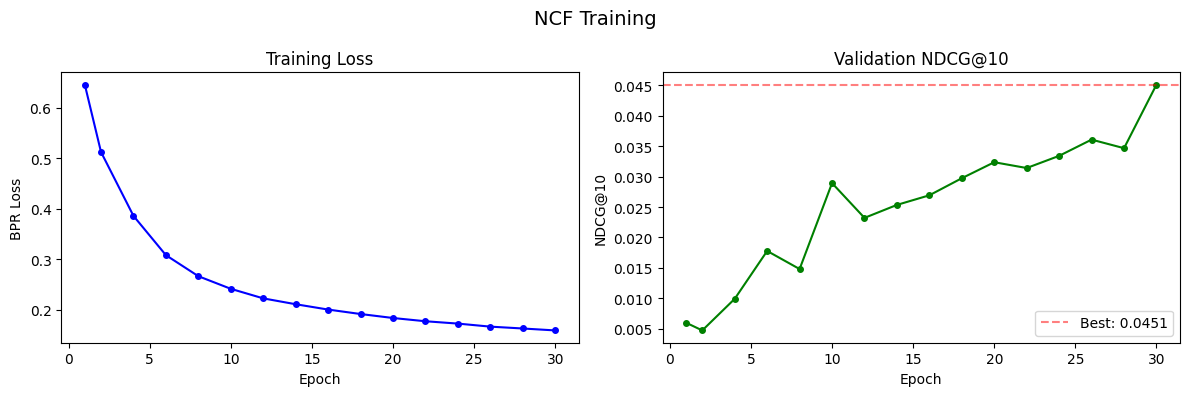

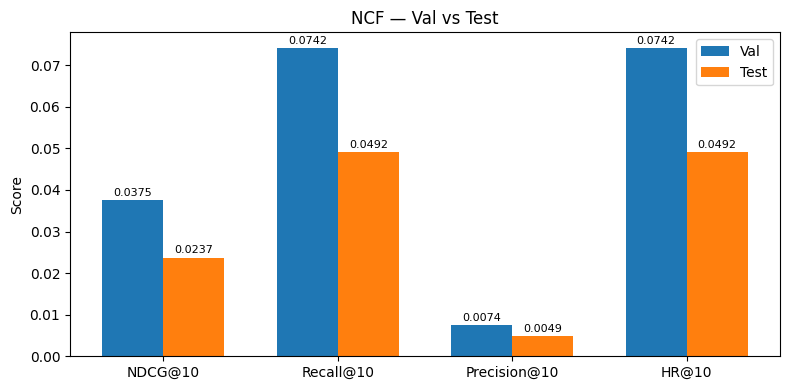


All saved to /kaggle/working


In [13]:
results = {
    "model": "NCF",
    "emb_dim_gmf": EMB_DIM_GMF,
    "emb_dim_mlp": EMB_DIM_MLP,
    "mlp_layers": MLP_LAYERS,
    "dropout": DROPOUT,
    "lr": LR,
    "val": val_metrics,
    "test": test_metrics,
}

with open(OUT_DIR / "ncf_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved: ncf_results.json")

pd.DataFrame(history).to_csv(OUT_DIR / "ncf_history.csv", index=False)
print("Saved: ncf_history.csv")

torch.save(model.state_dict(), OUT_DIR / "ncf_model.pt")
print("Saved: ncf_model.pt")

if history:
    hist_df = pd.DataFrame(history)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist_df["epoch"], hist_df["loss"], "b-o", markersize=4)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("BPR Loss")
    ax1.set_title("Training Loss")

    ax2.plot(hist_df["epoch"], hist_df["val_ndcg"], "g-o", markersize=4)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel(f"NDCG@{K}")
    ax2.set_title(f"Validation NDCG@{K}")
    ax2.axhline(y=best_ndcg, color="r", linestyle="--", alpha=0.5, label=f"Best: {best_ndcg:.4f}")
    ax2.legend()

    plt.suptitle("NCF Training", fontsize=14)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "ncf_training.png", dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
metric_keys = [f"NDCG@{K}", f"Recall@{K}", f"Precision@{K}", f"HR@{K}"]
val_vals = [val_metrics[m] for m in metric_keys]
test_vals = [test_metrics[m] for m in metric_keys]

x = np.arange(len(metric_keys))
w = 0.35
ax.bar(x - w/2, val_vals, w, label="Val")
ax.bar(x + w/2, test_vals, w, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylabel("Score")
ax.set_title("NCF — Val vs Test")
ax.legend()

for i, (v, t) in enumerate(zip(val_vals, test_vals)):
    ax.text(i - w/2, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.001, f"{t:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "ncf_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll saved to {OUT_DIR}")